<a href="https://colab.research.google.com/github/cccontre1/DIADM/blob/main/DIADM_TALLER3_KMEANS_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: PCA y K-means en salud

## 1. Introducción

El análisis de componentes principales (**PCA, Principal Component Analysis**) y el agrupamiento mediante **K-means clustering** son técnicas de **aprendizaje no supervisado** ampliamente utilizadas en investigación biomédica.
Mientras que PCA permite **reducir la dimensionalidad** de los datos manteniendo la mayor parte de la variabilidad, K-means busca **descubrir patrones ocultos** agrupando a los pacientes según sus características.

En este taller exploraremos estas dos herramientas aplicadas a problemas de salud. Comenzaremos con el dataset de **cáncer de mama ([Breast Cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html))**, donde trabajaremos con un escenario de clasificación binaria, y luego avanzaremos al dataset de **[Diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)**, que contiene un resultado clínico continuo asociado a la progresión de la enfermedad.

El objetivo es que aprendas a explorar, reducir y agrupar datos biomédicos, interpretando los resultados tanto desde una perspectiva técnica como clínica. Además, generarás visualizaciones que facilitan la comprensión de estructuras complejas en datasets de salud.


## 2. Objetivos

1. **Carga y estandarización de datos biomédicos**: preparar las variables clínicas para el análisis.
2. **Reducción de dimensionalidad con PCA**: visualizar pacientes en espacios de 2D que preservan la variabilidad más importante.
3. **Clustering con K-means**: identificar posibles subgrupos o fenotipos en los datos.
4. **Evaluación del clustering**: comparar resultados con etiquetas reales (Breast Cancer) o métricas como silhouette (Diabetes).
5. **Visualización de resultados**: generar gráficos en 2D para interpretar los patrones encontrados.
6. **Discusión clínica**: analizar cómo estas técnicas pueden apoyar el diagnóstico, el pronóstico y la investigación en salud.



## 3. Importar librerias

In [ ]:
# Librerias generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 4. Dataset cáncer de mama

El Breast Cancer Dataset (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) es un conjunto de datos ampliamente utilizado en el aprendizaje automático aplicado a la medicina. Su objetivo es clasificar tumores de mama en dos categorías:

- **M** = maligno  
- **B** = benigno  

### Características principales
- **Número de instancias:** 569  
- **Número de variables:** 30 (numéricas reales)  
- **Variable objetivo:** `Diagnosis` (M/B)  
- **Tarea principal:** Clasificación supervisada  

### Variables
Las características corresponden a medidas de núcleos celulares. Cada una se resume en **media, error estándar y máximo**, resultando en 30 variables en total. Entre ellas destacan:  

- **Radio:** media de distancias desde el centro al perímetro.  
- **Textura:** desviación estándar de los valores en escala de grises.  
- **Perímetro y Área.**  
- **Suavidad:** variación local de radios.  
- **Compacidad:** (perímetro² / área − 1).  
- **Concavidad y puntos cóncavos:** severidad y número de partes cóncavas del contorno.  
- **Simetría.**  
- **Dimensión fractal:** aproximación tipo “línea de costa”.  






_______________________________________
#### **Ejercicio 1**

1. Cargue el dataset desde scikit-learn. HINT: puede utilizar la función `load_breast_cancer` que viene integrada en scikit-learn
2. Inspeccione el tamaño de los datos, los tipos de datos, si existen valores faltantes y si existen filas duplicadas (HINT: puede usar el metodo `.duplicated()`).
3. Revise la distribución de clases (0=maligno, 1=benigno), en valores absolutos y porcentuales. Genere adicionalmente un grafico con estas distribuciones.
4. Explore la relación entre las variables presentes en el dataset mediante una matrix de correlación
____________________________

5. <font color='red'>Responda (**PREGUNTA 1 - TAREA**):</font>
    * <font color='red'>¿Qué indica la alta correlación entre ciertas variables?</font>
    * <font color='red'>¿Qué implicancias tiene para el análisis posterior?</font>


In [ ]:
# <CODE> 1. Cargue el dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
print(data.keys())
from sklearn.datasets import load_breast_cancer

X = data.data
y = data.target

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
# <CODE> 2.1 Estudie las dimensiones del dataset

# Convertir a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Agregar la variable objetivo (target)
df['target'] = data.target

# Ver primeras filas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# <CODE> 2.2 Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# <CODE> 2.3 Valores faltantes
df.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
# <CODE> 2.4 Evalue si existen filas duplicadas.
df.duplicated().sum()

np.int64(0)

In [ ]:
# <CODE> 3.1 Distribución de la clase en valores absolutos y porcentuales
# Ver clases
print(data.target_names)
# Conteo de clases
df['target'].value_counts()
print(df['target'].value_counts())
# Conteo porcentual
porcentaje = df['target'].value_counts(normalize=True) * 100
print(porcentaje)

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


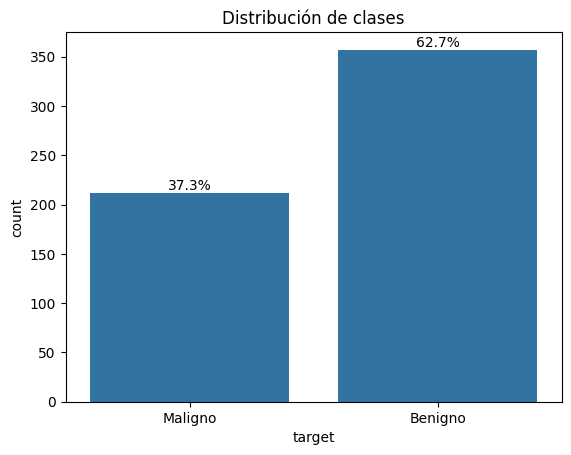

In [ ]:
# <CODE> 3.2 Graficamos la distribucion
df_plot = df.copy()
df_plot['target'] = df_plot['target'].map({0: 'Maligno', 1: 'Benigno'})

ax = sns.countplot(x='target', data=df_plot)

total = len(df_plot)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom')

plt.title("Distribución de clases")
plt.show()

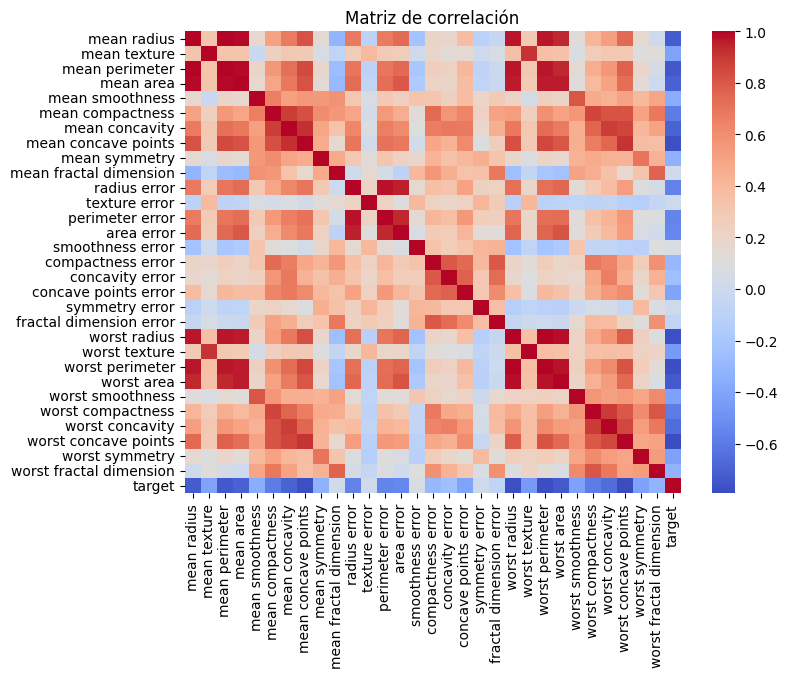

In [ ]:
# <CODE> 4. Correlación entre variables
# Matriz de correlación
corr = df.corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

#### **Ejercicio 2**


1. Estandarize las variables predictoras (es importante porque PCA es sensible a la escala). HINT: puedes usar `StandardScaler` de `sklearn.preprocessing`.
2. Aplique PCA reduciendo el dataset a **2 componentes principales**. HINT: use `PCA` de `sklearn.decomposition`.
3. Visualice los datos en un scatter plot de PC1 vs PC2, coloreando los puntos por la clase real (0=maligno, 1=benigno).
4. Muestre la **varianza explicada** por cada componente.
5. Identifique las **variables más influyentes** en cada componente principal.
______________________________
6. <font color='red'>Responda (**PREGUNTA 2 - TAREA**):</font>
   * <font color='red'>¿Qué significa que los dos primeros componentes expliquen un alto porcentaje de la varianza?</font>
   * <font color='red'>¿Por qué es útil reducir la dimensionalidad a 2D en este caso?</font>



In [ ]:
# <CODE> 1. Estandarización
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('target', axis=1))
df_scaled = pd.DataFrame(df_scaled, columns=df.columns[:-1])
df_scaled.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [ ]:
# <CODE> 2. PCA con 2 componentes
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)
X_pca


array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]])

<Axes: >

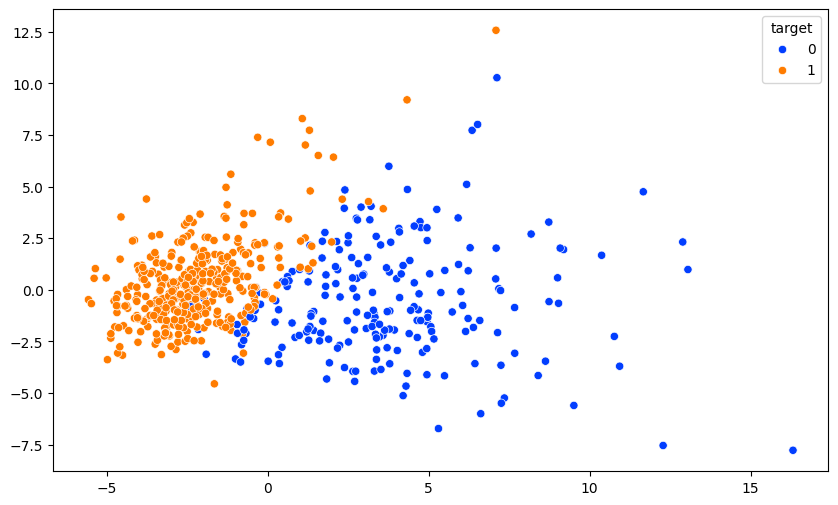

In [ ]:
# <CODE> 3. Visualización PC1 vs PC2
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['target'], palette='bright')

In [ ]:
# <CODE> 4. Varianza explicada
print(pca.explained_variance_ratio_)
#Interpretación:

#PC1 → 44% de la varianza
#PC2 → 19%
#Total ≈ 63%

[0.44272026 0.18971182]


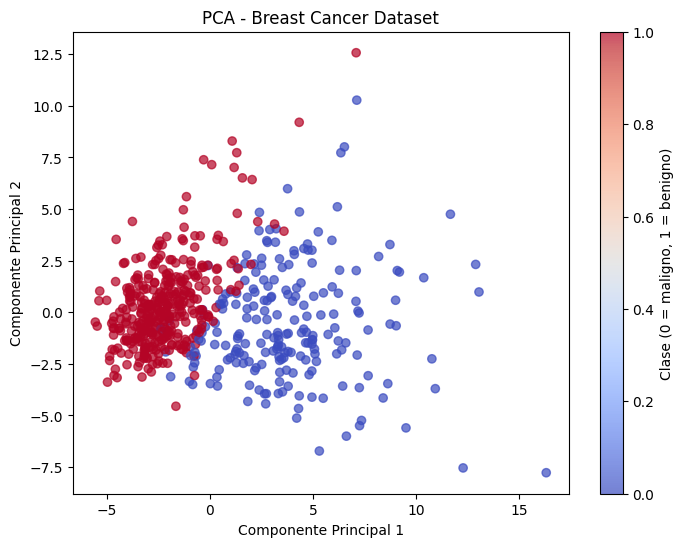

In [ ]:
# <CODE> 5. Variables más influyentes en PC1 y PC2
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA - Breast Cancer Dataset")

plt.colorbar(label="Clase (0 = maligno, 1 = benigno)")
plt.show()


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=data.feature_names
)

loadings.head()

,PC1,PC2
mean radius,0.218902,-0.233857
mean texture,0.103725,-0.059706
mean perimeter,0.227537,-0.215181
mean area,0.220995,-0.231077
mean smoothness,0.142590,0.186113


In [ ]:
pc1_top = loadings['PC1'].abs().sort_values(ascending=False)
pc2_top = loadings['PC2'].abs().sort_values(ascending=False)

print("Top PC1:")
print(pc1_top.head(10))

print("\nTop PC2:")
print(pc2_top.head(10))

Top PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
worst concavity         0.228768
worst radius            0.227997
mean perimeter          0.227537
worst area              0.224871
mean area               0.220995
Name: PC1, dtype: float64

Top PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
mean area                  0.231077
worst radius               0.219866
worst area                 0.219352
mean perimeter             0.215181
smoothness error           0.204430
Name: PC2, dtype: float64


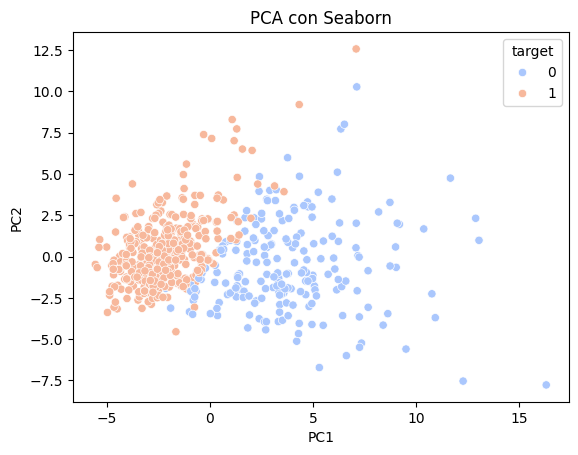

In [ ]:
import seaborn as sns

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='target',
    palette='coolwarm'
)

plt.title("PCA con Seaborn")
plt.show()


Responda (PREGUNTA 2 - TAREA):
¿Qué significa que los dos primeros componentes expliquen un alto porcentaje de la varianza? ¿Por qué es útil reducir la dimensionalidad a 2D en este caso?

Alta varianza en PC1 (44%) y PC2(19%) → capturan la mayor parte de la información de los datos. Representa el dataset en 2D sin perder demasiada información. Indica que el problema tiene estructura clara. PC1 por si sola logra separar el target.
El ser dos componentes facilita visualización, interpretación y análisis, sobretodo al graficar. Elimina el ruido.


#### **Ejercicio 3**

1. Aplicar **K-means clustering** con `k=2` sobre los datos clínicos estandarizados (sin usar etiquetas). HINT: usa `KMeans` de `sklearn.cluster`.
2. Visualice los pacientes en 2D usando una proyección PCA **solo para graficar**.
3. Repetir el proceso aplicando primero **PCA** para reducir las dimensiones a 2 y luego correr **K-means** en ese espacio.
__________________

4. <font color='red'>Responda (**PREGUNTA 3 - TAREA**):
   * <font color='red'>¿Los clusters se ven más definidos después de PCA?</font>
   * <font color='red'>¿Es posible intuir la separación entre tipos de pacientes sin tener las etiquetas?</font>
   * <font color='red'>¿Como se comparan los clusters con las etiquetas reales?</font>


In [ ]:
# <CODE> 1. K-means directo en datos originales
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df_scaled)

clusters = kmeans.labels_

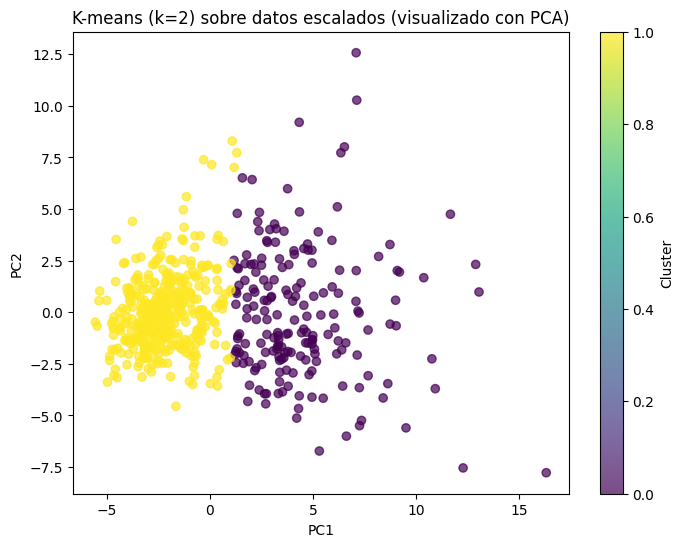

In [ ]:
# <CODE> 2. Proyectamos a 2D con PCA solo para visualizar
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA solo para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

# Gráfico
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means (k=2) sobre datos escalados (visualizado con PCA)")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
import pandas as pd

pd.crosstab(clusters, df['target'])

target,0,1
row_0,,
0,175,13
1,37,344


In [ ]:
# <CODE> 3. K-means sobre espacio PCA
# Reducir a 2 dimensiones
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(df_scaled)

# K-means en espacio reducido
kmeans_pca = KMeans(n_clusters=2, random_state=42)
kmeans_pca.fit(X_pca_2)

clusters_pca = kmeans_pca.labels_

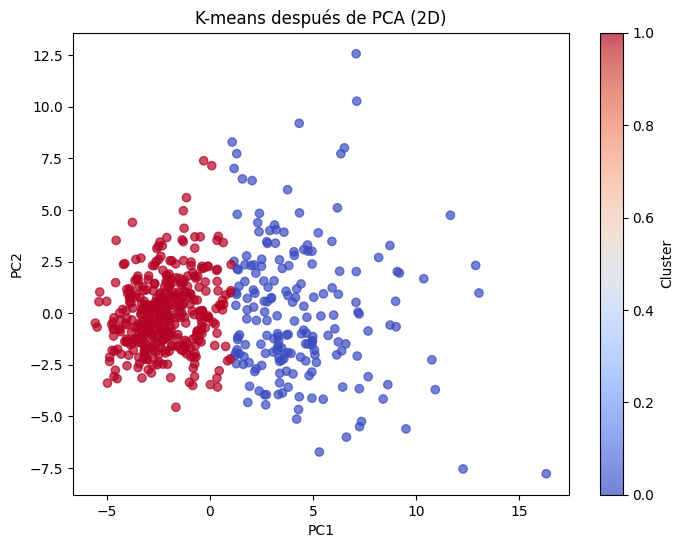

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=clusters_pca, cmap='coolwarm', alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means después de PCA (2D)")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
print("K-means sin PCA:")
print(pd.crosstab(clusters, df['target']))

print("\nK-means con PCA:")
print(pd.crosstab(clusters_pca, df['target']))

K-means sin PCA:
target    0    1
row_0           
0       175   13
1        37  344

K-means con PCA:
target    0    1
row_0           
0       175   16
1        37  341


Responda (PREGUNTA 3 - TAREA):

¿Los clusters se ven más definidos después de PCA?
No cambia significativamente, los clusters ya se identificaban sin el PCA.

¿Es posible intuir la separación entre tipos de pacientes sin tener las etiquetas? Sí, sin etiquetas se distinguen dos tipos de pacientes o más bien de tumores.


¿Como se comparan los clusters con las etiquetas reales? Buen comportamiento, para maligno 93% precisión (175/(175+13)) y para benigno 90% precisión (344/(344+37))

#### **Ejercicio 4**

1. Recuerde que en la práctica muchas veces **no tenemos etiquetas** (no sabemos si un tumor es benigno o maligno).Para evaluar qué tan bien separa K-means los grupos, podemos usar el **Silhouette Score**: HINT: use `silhouette_score` de `sklearn.metrics`.
   * Valores cercanos a **1** → clusters bien definidos y separados.
   * Valores cercanos a **0** → clusters solapados.
2. Calcule el Silhouette Score para distintos valores de `k` (ej: 2, 3, 4, 5 y 6).
3. Identifique qué número de clusters logra la mejor separación.
_____________________________
4. <font color='red'>Responda (**PREGUNTA 4 - TAREA**):</font>
   * <font color='red'>¿Qué valor de `k` entrega el mejor Silhouette Score?</font>
   * <font color='red'>¿Qué significa esto en el contexto clínico?</font>



In [ ]:
# <CODE> 1. Silhouette Score para distintos k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5, 6]
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)
    scores.append(score)

    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.3447
k = 3, Silhouette Score = 0.3152
k = 4, Silhouette Score = 0.2742
k = 5, Silhouette Score = 0.1645
k = 6, Silhouette Score = 0.1451


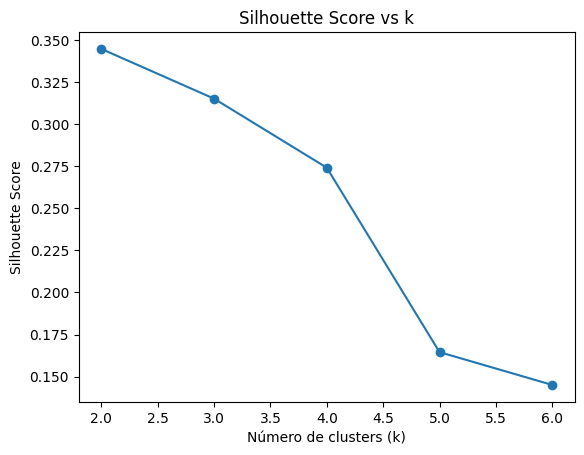

In [ ]:
# <CODE> 2. Mostramos el resultado de Silhouette Score
import matplotlib.pyplot as plt

plt.plot(k_values, scores, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

Responda (PREGUNTA 4 - TAREA):
¿Qué valor de k entrega el mejor Silhouette Score?
K = 2 entrega mejor score

¿Qué significa esto en el contexto clínico?
Que hay dos grupos naturales en los datos. Coincidiendo con el target: benigno/maligno.



## 5. Dataset Diabetes

El dataset Diabetes de scikit-learn contiene información clínica de 442 pacientes con 10 variables predictoras estandarizadas:
* Edad
* sexo
* IMC (bmi)
* presión arterial (bp)
* 6 medidas séricas (s1–s6).

La variable objetivo (target) corresponde a una medida continua de la progresión de la enfermedad un año después de la toma de datos iniciales.


#### **Ejercicio 5**

1. Cargue la data y estandarice las variables predictoras (las que corresponden a las 6 medicas séricas s1-s6) con `StandardScaler`. HINT: puede usar `load_diabetes` de `sklearn.datasets`.
2. Aplique PCA para reducir los datos a **2 componentes principales**.
3. Grafique un scatter plot con PC1 y PC2 en los ejes, coloreando cada paciente según su **progresión de la enfermedad (`target`)**.
   * Use un **gradiente de color** para representar los valores de progresión.
<font color='red'>4. Responda (**PREGUNTA 5 - TAREA**):</font>
   * <font color='red'>¿Se observa un patrón de gradiente de colores en la proyección PCA?</font>
   * <font color='red'>¿Qué sugiere esto sobre la capacidad de PCA de resumir la variabilidad relacionada con la progresión?</font>



In [ ]:
# <CODE> 1. Cargar dataset
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.keys())
print(data.feature_names)

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [ ]:
import pandas as pd

df = pd.DataFrame(data.data, columns=data.feature_names)

# Seleccionar variables séricas
df_s = df[['s1', 's2', 's3', 's4', 's5', 's6']]

df_s.head()

,s1,s2,s3,s4,s5,s6
0,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_s)

# Convertir a DataFrame (opcional)
X_scaled = pd.DataFrame(X_scaled, columns=df_s.columns)

In [ ]:
# <CODE> 2. PCA con 2 componentes
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print("Varianza total:", pca.explained_variance_ratio_.sum())

[0.54594331 0.21808828]
Varianza total: 0.7640315933745523


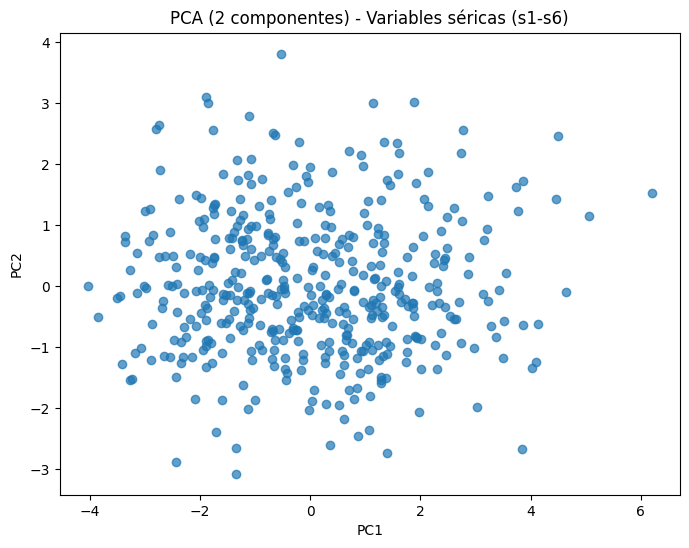

In [ ]:
# <CODE> 3. Visualización coloreada por target (progresión)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 componentes) - Variables séricas (s1-s6)")

plt.show()

4. Responda (PREGUNTA 5 - TAREA):

¿Se observa un patrón de gradiente de colores en la proyección PCA?
No hay gradiente claro

¿Qué sugiere esto sobre la capacidad de PCA de resumir la variabilidad relacionada con la progresión?
Las variables s1–s6 no explican bien por sí solas la progresión en 2 dimensiones

#### <font color='red'>**Ejercicio 6 (TODO ESTE EJERCICIO ES PARTE DE LA TAREA)**</font>

<font color='red'>Para evaluar si es posible categorizar la progresión de la enfermedad, utilice **K-means** para **agrupar** pacientes en el plano reducido por **PCA** y evalúe si estos grupos muestran **diferencias en la progresión** de la enfermedad.</font>

1. <font color='red'>Use la misma proyección **PCA (PC1, PC2)** obtenida en el ejercicio anterior.</font>
2. <font color='red'>Aplique **K-means** con distintos valores de `k` (p. ej., 2, 3, 4, ...).</font>
3. <font color='red'>Elija el mejor `k` con **Silhouette Score**.</font>
4. <font color='red'>Visualice **PC1 vs PC2** coloreando por **cluster**.</font>
5. <font color='red'>Compare la **progresión (`Y`)** entre clusters (boxplots) y realice una prueba no paramétrica (**Kruskal–Wallis**) para evaluar diferencias globales entre grupos. Hint: use `kruskal` de `scipy.stats`.</font>
6. <font color='red'>Responda:</font>
   * <font color='red'>¿Qué `k` maximiza el Silhouette Score?</font>
   * <font color='red'>¿Los clusters muestran **diferencias significativas** en progresión?</font>
   * <font color='red'>¿Cómo interpretarías clínicamente estos grupos?</font>



In [ ]:
# <CODE> 1. Compara valores de k y elige por Silhouette
from sklearn.cluster import KMeans

k_values = [2, 3, 4, 5, 6]
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

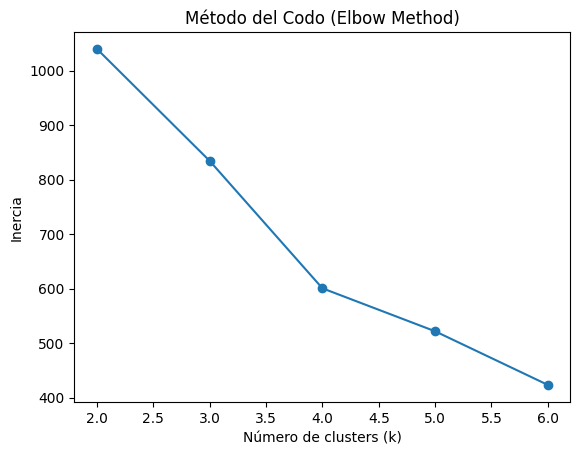

In [ ]:
# <CODE> 2. Seleccion del mejor k
import matplotlib.pyplot as plt

plt.plot(k_values, inertia, marker='o')
plt.title("Método del Codo (Elbow Method)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.show()

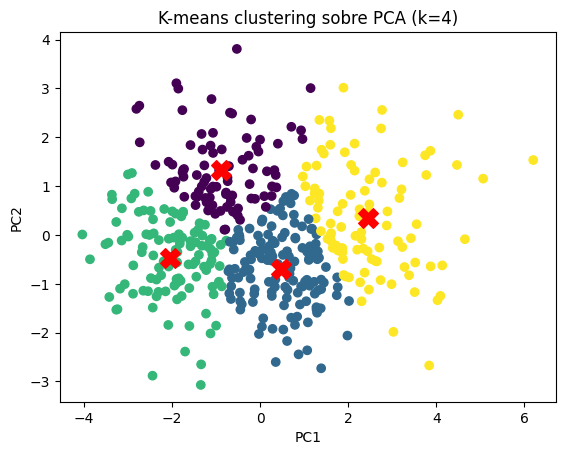

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200)

plt.title("K-means clustering sobre PCA (k=4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [ ]:
# <CODE> 3. Comparar la progresión entre clusters (boxplot + puntos)
import pandas as pd

df_clusters = pd.DataFrame({
    'cluster': clusters,
    'target': data.target
})

df_clusters.groupby('cluster')['target'].mean()

,target
cluster,
0,108.089888
1,176.727273
2,119.160714
3,193.928571


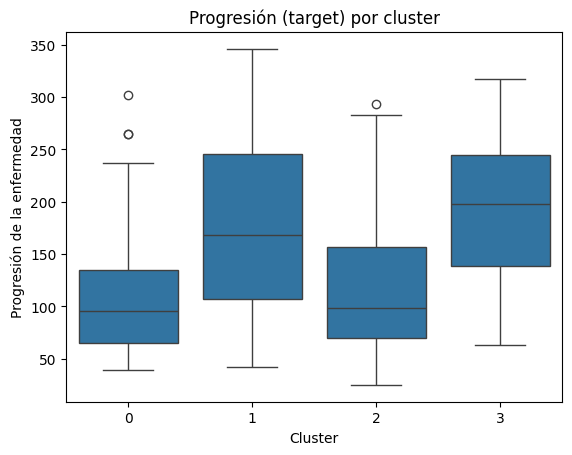

In [ ]:
#Boxplots por cluster
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='cluster', y='target', data=df_clusters)
plt.title("Progresión (target) por cluster")
plt.xlabel("Cluster")
plt.ylabel("Progresión de la enfermedad")
plt.show()

In [ ]:
#Test de Kruskal–Wallis
from scipy.stats import kruskal

groups = [df_clusters[df_clusters['cluster'] == c]['target'] for c in df_clusters['cluster'].unique()]

stat, p_value = kruskal(*groups)

print(f"Estadístico: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Estadístico: 95.1088
p-value: 0.0000


In [ ]:
#Silhouette Score para distintos k
from sklearn.metrics import silhouette_score

k_values = [2, 3, 4, 5, 6]
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

for k, s in zip(k_values, scores):
    print(f"k={k}: silhouette={s:.3f}")

k=2: silhouette=0.417
k=3: silhouette=0.321
k=4: silhouette=0.347
k=5: silhouette=0.312
k=6: silhouette=0.334


Responda:
¿Qué k maximiza el Silhouette Score?

K=2


¿Los clusters muestran diferencias significativas en progresión?

Muestran diferencias en progresion, en particular el 0 y 2 muestra menor progresión mientras que el cluster 1 y 3 muestra mayor progresion. Pero de todas formas existe solapamiento en funcion al target.


¿Cómo interpretarías clínicamente estos grupos?

Clínicamente, estos grupos podrían interpretarse como subpoblaciones de pacientes con distinto riesgo de progresión por perfiles metabolicos similares, lo que podría ser útil para estratificación de riesgo o toma de decisiones terapéuticas, pero con prudencia ya que existe solapamiento considerable. Por lo tanto, estos grupos deben interpretarse con cautela y no como categorías clínicas discretas, sino como una aproximación exploratoria a patrones subyacentes en los datos. Esto cobra sentido ya que la progresión de la diabetes es multifactorial, no separable en ejes simples.